
# Hệ thống Dự đoán Rủi ro Tín dụng và Đề xuất Thu hồi nợ

Demo minh họa toàn bộ pipeline: Data Understanding & Preparation → Feature Engineering →
Model Training & Tuning → Evaluation & Interpretation → Priority Ranking cho thu hồi nợ.

Dữ liệu: UCI *Default of Credit Card Clients* (30.000 khách hàng, 23 biến đầu vào).
Đối chiếu với paper gốc: Yeh & Lien (2009), *Expert Systems with Applications* 36, 2473-2480.

Notebook này gọi lại các hàm đã viết trong `src/` (xem `../src/`) — mỗi cell tương ứng
với một bước trong kế hoạch 3 sprint của đề xuất dự án (`../docs/proposal.docx`).


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # de import duoc package "src"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import clean, load_raw, split
from src.evaluate import build_metrics_table, build_paper_comparison_table
from src.features import add_derived_features, build_preprocessor, compute_vif
from src.models import train_all_models
from src.priority import build_priority_ranking
from src.config import BILL_AMT_COLS, PAY_COLS, TARGET_COL

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## Sprint 1 — Data Understanding & Preparation

### 1.1. Khám phá dữ liệu (EDA)

In [2]:
df_raw = load_raw()
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Ty le vo no (default): 22.12%


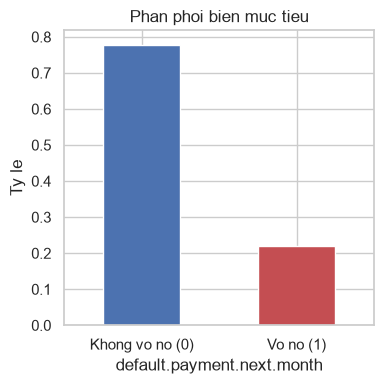

In [3]:
# Phan phoi bien muc tieu -- kiem tra muc do mat can bang
default_rate = df_raw[TARGET_COL].mean()
print(f"Ty le vo no (default): {default_rate:.2%}")

fig, ax = plt.subplots(figsize=(4, 4))
df_raw[TARGET_COL].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Khong vo no (0)", "Vo no (1)"], rotation=0)
ax.set_ylabel("Ty le")
ax.set_title("Phan phoi bien muc tieu")
plt.tight_layout()
plt.show()

In [4]:
# Gia tri bat thuong trong EDUCATION va MARRIAGE (truoc khi lam sach)
print("EDUCATION (0, 5, 6 khong nam trong dinh nghia goc 1-4):")
print(df_raw["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE (0 khong nam trong dinh nghia goc 1-3):")
print(df_raw["MARRIAGE"].value_counts().sort_index())

EDUCATION (0, 5, 6 khong nam trong dinh nghia goc 1-4):
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE (0 khong nam trong dinh nghia goc 1-3):
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


### 1.2. Làm sạch dữ liệu

- Đổi tên `PAY_0` → `PAY_1` để nhất quán với `PAY_2..PAY_6`.
- `EDUCATION`: gộp `0, 5, 6` (không thuộc định nghĩa gốc) vào nhóm `4 = others`.
- `MARRIAGE`: gộp `0` (không thuộc định nghĩa gốc) vào nhóm `3 = others`.

In [5]:
df_clean = clean(df_raw)
print("EDUCATION sau khi lam sach:", sorted(df_clean["EDUCATION"].unique()))
print("MARRIAGE sau khi lam sach:", sorted(df_clean["MARRIAGE"].unique()))
print("Co cot PAY_1:", "PAY_1" in df_clean.columns, "| Con PAY_0:", "PAY_0" in df_clean.columns)

EDUCATION sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3)]
Co cot PAY_1: True | Con PAY_0: False


### 1.3. Feature engineering & kiểm tra đa cộng tuyến

`BILL_AMT1..BILL_AMT6` thường tương quan rất cao với nhau (dư nợ hàng tháng
không biến động nhiều). Ta kiểm tra bằng VIF (Variance Inflation Factor) và
thêm các đặc trưng tổng hợp (`AVG_BILL_AMT`, `BILL_AMT_TREND`, `MAX_DELAY`, ...)
để giảm phụ thuộc vào từng cột `BILL_AMT` riêng lẻ — đặc biệt hữu ích cho
Logistic Regression.

In [6]:
vif_table = compute_vif(df_clean, BILL_AMT_COLS)
print(vif_table)  # VIF > 10 -> da cong tuyen manh

     feature        VIF
1  BILL_AMT2  23.660203
4  BILL_AMT5  22.604274
3  BILL_AMT4  19.294916
2  BILL_AMT3  15.685823
0  BILL_AMT1  15.676637
5  BILL_AMT6  13.820638


In [7]:
df_fe = add_derived_features(df_clean)
new_cols = ["AVG_BILL_AMT", "AVG_PAY_AMT", "BILL_AMT_TREND", "MAX_DELAY", "AVG_DELAY", "PAY_TO_BILL_RATIO"]
df_fe[new_cols].describe()

,AVG_BILL_AMT,AVG_PAY_AMT,BILL_AMT_TREND,MAX_DELAY,AVG_DELAY,PAY_TO_BILL_RATIO
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,44976.945200,5275.232094,12351.570500,0.438733,-0.182439,0.373507
std,63260.721860,10137.946323,43922.421534,1.345154,0.982176,0.842815
min,-56043.166667,0.000000,-428791.000000,-2.000000,-2.000000,-10.000000
25%,4781.333333,1113.291667,-2963.000000,0.000000,-0.833333,0.040952
50%,21051.833333,2397.166667,923.000000,0.000000,0.000000,0.084932
75%,57104.416667,5583.916667,19793.750000,2.000000,0.000000,0.586922
max,877313.833333,627344.333333,708323.000000,8.000000,6.000000,10.000000


### 1.4. Chia tập train / validation / test (stratified)

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = split(df_fe)

print(f"Train: {X_train.shape}, default rate = {y_train.mean():.2%}")
print(f"Val:   {X_val.shape}, default rate = {y_val.mean():.2%}")
print(f"Test:  {X_test.shape}, default rate = {y_test.mean():.2%}")

Train: (18000, 29), default rate = 22.12%
Val:   (6000, 29), default rate = 22.12%
Test:  (6000, 29), default rate = 22.12%


## Sprint 2 — Model Building, Training & Tuning

Tiền xử lý (one-hot cho biến phân loại + chuẩn hoá biến số), sau đó huấn luyện
và tinh chỉnh siêu tham số cho 4 mô hình: **Logistic Regression** (baseline,
đối chiếu paper gốc), **Random Forest**, **XGBoost**, **Neural Network (MLP)**
(đối chiếu Neural Network paper gốc). Mất cân bằng lớp được xử lý bằng
`class_weight="balanced"` (LR, RF), `scale_pos_weight` (XGBoost), hoặc
oversampling thủ công (MLP — do `MLPClassifier` không hỗ trợ `class_weight`).

In [9]:
feature_cols = list(X_train.columns)
preprocessor = build_preprocessor(feature_cols)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())

print("So chieu sau tien xu ly:", X_train_t.shape[1])

So chieu sau tien xu ly: 35


In [10]:
%%time
trained = train_all_models(X_train_t, y_train.to_numpy(), X_val_t, y_val.to_numpy())

for name, info in trained.items():
    print(f"{name:22s} best_params={info['best_params']}  val_auc={info['val_auc']:.4f}")

Logistic Regression    best_params={'C': 10.0}  val_auc=0.7223
Random Forest          best_params={'n_estimators': 400, 'max_depth': 10}  val_auc=0.7775
XGBoost                best_params={'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}  val_auc=0.7759
Neural Network         best_params={'hidden_layer_sizes': (32,), 'alpha': 0.001}  val_auc=0.7667
CPU times: total: 2min 9s
Wall time: 32.1 s


## Sprint 3 — Evaluation, Interpretation & Reporting

### 3.1. Đánh giá trên tập test

In [11]:
metrics_table = build_metrics_table(trained, X_test_t, y_test.to_numpy())
metrics_table

,model,best_params,val_auc,test_auc_roc,test_accuracy,test_precision,test_recall,test_f1
0,XGBoost,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.775868,0.787950,0.763500,0.474973,0.657875,0.551659
1,Random Forest,"{'n_estimators': 400, 'max_depth': 10}",0.777504,0.782725,0.776000,0.494769,0.605878,0.544715
2,Neural Network,"{'hidden_layer_sizes': (32,), 'alpha': 0.001}",0.766689,0.778175,0.747500,0.451194,0.654861,0.534276
3,Logistic Regression,{'C': 10.0},0.722318,0.744591,0.732833,0.431548,0.655614,0.520491


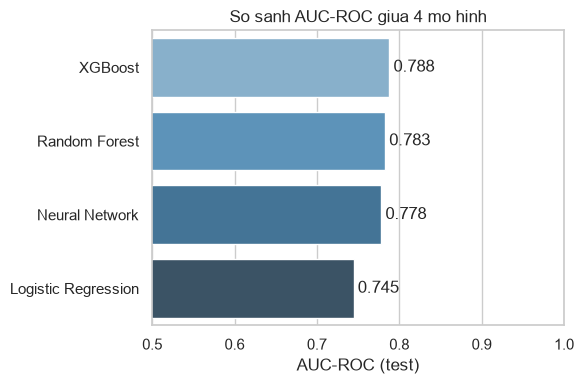

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=metrics_table, x="test_auc_roc", y="model", hue="model", legend=False, palette="Blues_d", ax=ax)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC-ROC (test)")
ax.set_ylabel("")
ax.set_title("So sanh AUC-ROC giua 4 mo hinh")
for i, v in enumerate(metrics_table["test_auc_roc"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

### 3.2. So sánh với paper gốc Yeh & Lien (2009)

Paper gốc dùng **area ratio trong lift chart** (Table 1) thay vì AUC-ROC để so
sánh mô hình, với lý do dữ liệu mất cân bằng. Area ratio có cùng định nghĩa
với hệ số Gini chuẩn hoá, nên ta quy đổi gần đúng `AUC ≈ (area_ratio + 1) / 2`
(xem `src/config.py`) để đối chiếu. Đây là quy đổi tương đối — không phải
con số AUC-ROC do tác giả gốc trực tiếp công bố — nên chênh lệch % cải thiện
dưới đây chỉ mang tính tham khảo, không phải kết luận tuyệt đối.

In [13]:
comparison_table = build_paper_comparison_table(metrics_table)
comparison_table

,model,auc_2026,auc_approx_2009,improvement_pct,note
0,XGBoost,0.787950,NaN,NaN,khong co trong paper goc (2009)
1,Random Forest,0.782725,NaN,NaN,khong co trong paper goc (2009)
2,Neural Network,0.778175,0.77,1.061732,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"
3,Logistic Regression,0.744591,0.72,3.415480,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"


### 3.3. Diễn giải mô hình (SHAP feature importance)

Phân tích SHAP trên mô hình tốt nhất để xác định các đặc trưng ảnh hưởng
mạnh nhất đến khả năng vỡ nợ.

In [14]:
from src.interpret import compute_shap_values, top_features_by_shap

best_model_name = metrics_table.iloc[0]["model"]
best_model = trained[best_model_name]["model"]
print("Mo hinh tot nhat theo AUC-ROC tren test:", best_model_name)

shap_values, X_sample = compute_shap_values(best_model, X_test_t, feature_names)
top_features = top_features_by_shap(shap_values, feature_names, top_n=15)
top_features

Mo hinh tot nhat theo AUC-ROC tren test: XGBoost


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_abs_shap
0,num__MAX_DELAY,0.508216
1,num__PAY_1,0.252168
2,num__LIMIT_BAL,0.176697
3,num__AVG_DELAY,0.090529
4,num__BILL_AMT1,0.066757
5,num__PAY_AMT2,0.066650
6,num__PAY_AMT1,0.065537
7,num__PAY_TO_BILL_RATIO,0.064868
8,num__AVG_BILL_AMT,0.060596
9,num__BILL_AMT_TREND,0.054470


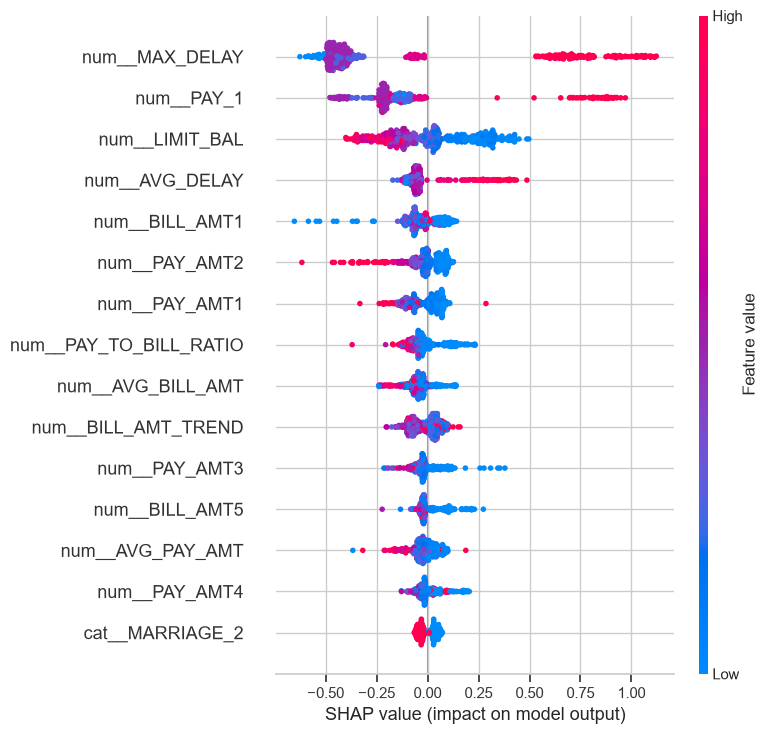

In [15]:
import shap

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=15, show=True)

### 3.4. Công cụ xếp hạng ưu tiên thu hồi nợ

```
priority_score = risk_score × mức_độ_trễ_hạn
```

- `risk_score`: xác suất vỡ nợ do mô hình tốt nhất (xem mục 3.1) dự báo trên tập test.
- `mức_độ_trễ_hạn`: `max(PAY_1..PAY_6, 0)` — chỉ tính số tháng trễ hạn thực tế (giá trị dương),
  bỏ qua các trạng thái "trả đúng hạn / dùng tín dụng xoay vòng / không phát sinh dư nợ" (≤ 0).

Khách hàng có `priority_score` cao nhất là nhóm **vừa rủi ro vỡ nợ cao, vừa đã trễ hạn nhiều kỳ** —
đúng nhóm bộ phận thu hồi nợ nên liên hệ trước.

In [16]:
risk_scores = best_model.predict_proba(X_test_t)[:, 1]
priority_ranking = build_priority_ranking(X_test, X_test.index.to_series(name="ID"), risk_scores)

print("Top 10 khach hang uu tien thu hoi no cao nhat:")
priority_ranking.head(10)

Top 10 khach hang uu tien thu hoi no cao nhat:


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,4388,0.892530,8,7.140237
1,2,750,0.878362,8,7.026893
2,3,13713,0.831621,8,6.652966
3,4,13407,0.939739,7,6.578175
4,5,20722,0.939557,7,6.576897
5,6,20255,0.938422,7,6.568957
6,7,9672,0.937248,7,6.560738
7,8,16789,0.936862,7,6.558035
8,9,24168,0.935559,7,6.548910
9,10,29771,0.934093,7,6.538654


**Case study:** kiểm tra tính hợp lý của thứ hạng — so sánh 3 khách hàng ưu
tiên cao nhất với 3 khách hàng có `risk_score` cao nhưng `delay_severity = 0`
(rủi ro cao nhưng hiện chưa trễ hạn, nên chưa cần ưu tiên liên hệ ngay).

In [17]:
print("=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):")
display(priority_ranking.head(3))

high_risk_no_delay = priority_ranking[priority_ranking["delay_severity"] == 0].sort_values(
    "risk_score", ascending=False
).head(3)
print("\n=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):")
display(high_risk_no_delay)

=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,4388,0.892530,8,7.140237
1,2,750,0.878362,8,7.026893
2,3,13713,0.831621,8,6.652966



=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):


,priority_rank,ID,risk_score,delay_severity,priority_score
4203,4204,20818,0.616561,0,0.0
2907,2908,24535,0.607303,0,0.0
5261,5262,13030,0.604190,0,0.0


## Kết luận

- 4 mô hình đã được huấn luyện và so sánh trên cùng tập test (AUC-ROC, Accuracy,
  Precision, Recall, F1) — xem bảng ở mục 3.1.
- Mô hình tốt nhất được đối chiếu với kết quả (quy đổi) của paper gốc Yeh & Lien (2009).
- SHAP xác định các đặc trưng ảnh hưởng mạnh nhất đến khả năng vỡ nợ (mục 3.3).
- Bảng `priority_score` (mục 3.4) và file `reports/priority_ranking.csv` (sinh bởi
  `python -m src.pipeline`) là sản phẩm ứng dụng thực tiễn hỗ trợ bộ phận thu hồi nợ
  ưu tiên liên hệ khách hàng.

**Hạn chế:** demo dừng ở mức notebook, chưa tích hợp CRM/hệ thống thu hồi nợ thực tế;
việc quy đổi AUC từ area ratio của paper gốc chỉ mang tính tham khảo tương đối.